# Trực quan số lượng

Tổng số khách hàng rời bỏ: 2037
Tỷ lệ rời bỏ tổng thể: 20.37%

--- Tỷ lệ rời bỏ theo các đặc điểm ---
        count  churn_count  churn_rate (%)
gender                                    
Female   4543         1139       25.071539
Male     5457          898       16.455928
         count  churn_count  churn_rate (%)
country                                    
France    5014          810       16.154767
Germany   2509          814       32.443204
Spain     2477          413       16.673395
                 count  churn_count  churn_rate (%)
products_number                                    
1                 5084         1409       27.714398
2                 4590          348        7.581699
3                  266          220       82.706767
4                   60           60      100.000000
             count  churn_count  churn_rate (%)
credit_card                                    
0             2945          613       20.814941
1             7055         1424       20.184266
  

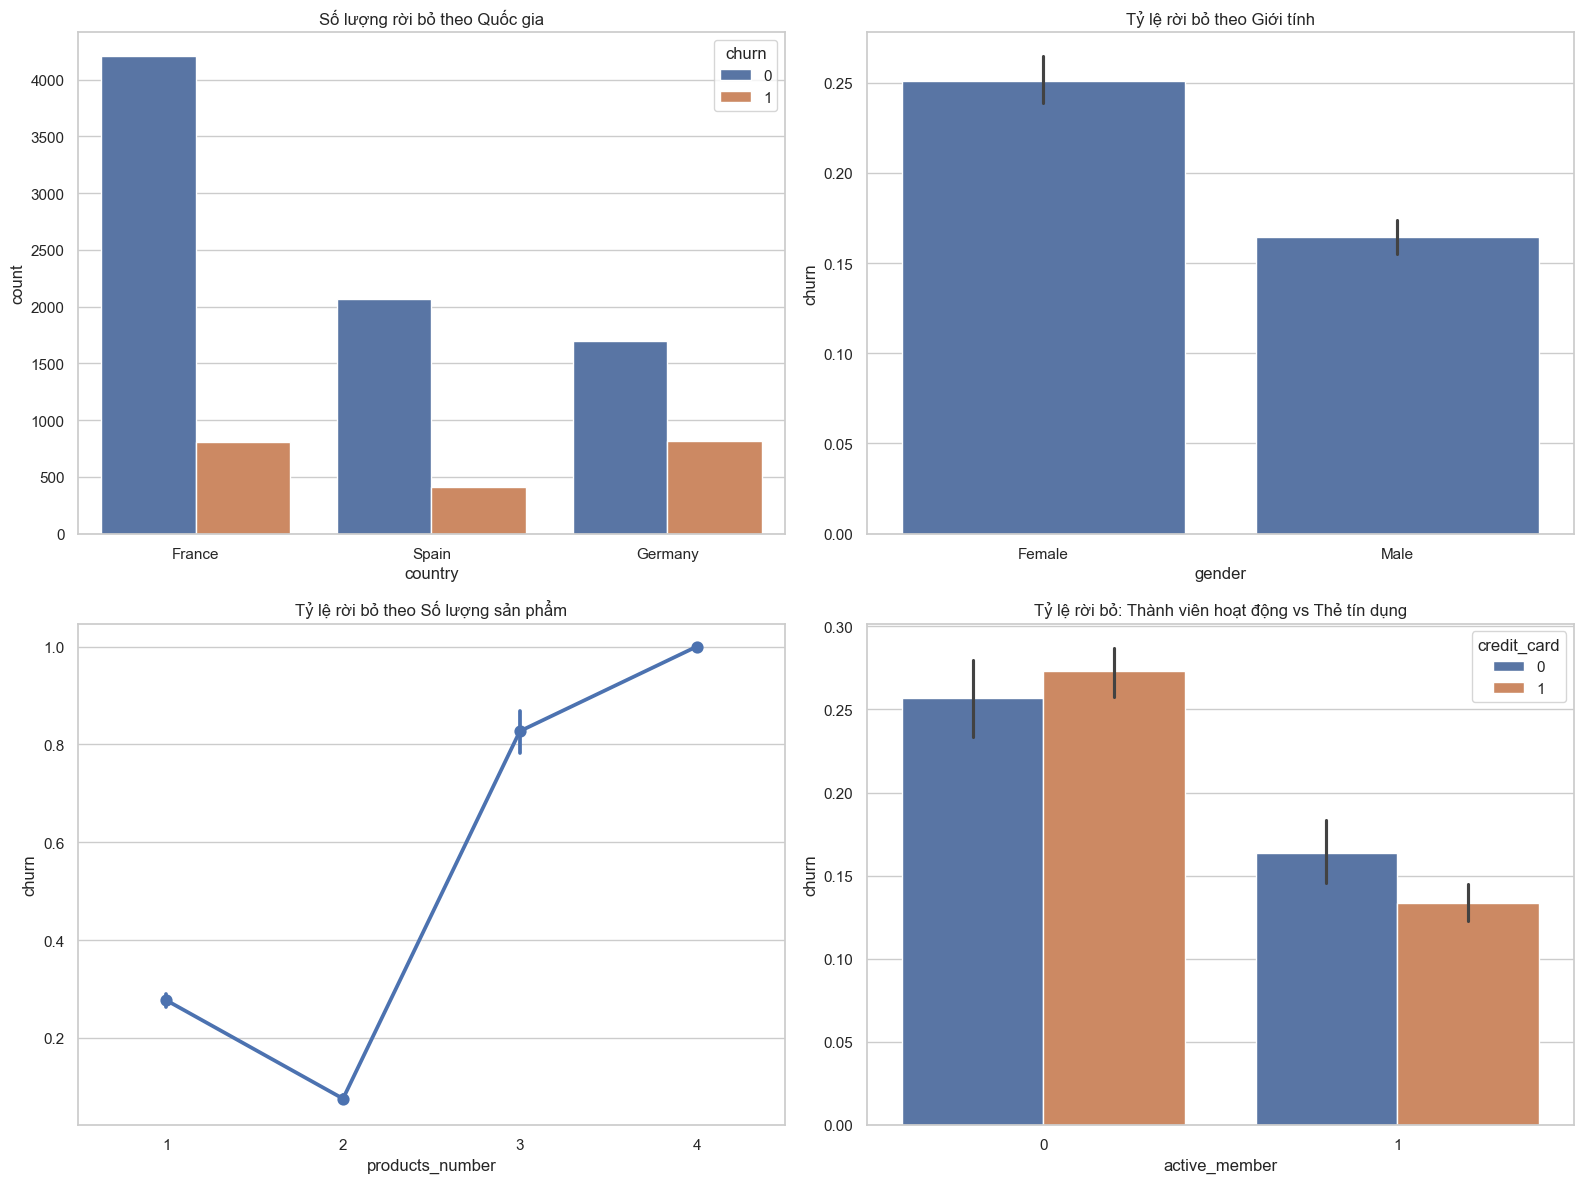

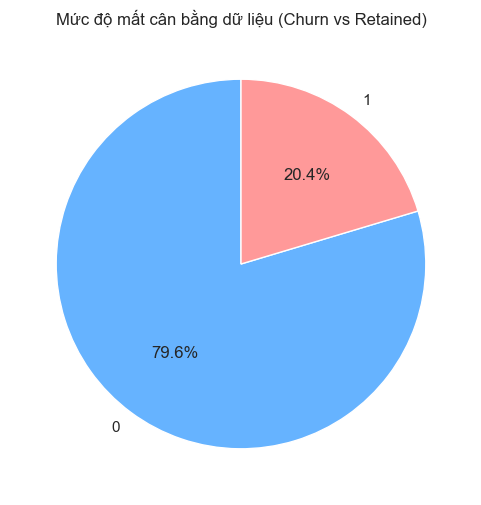

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# 1. Đọc dữ liệu
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- PHẦN 1: TÍNH TOÁN VÀ PHÂN TÍCH SỐ LIỆU ---

# Tổng số lượng khách hàng rời bỏ (Churn)
total_churn = df['churn'].sum()
churn_rate = (total_churn / len(df)) * 100

print(f"Tổng số khách hàng rời bỏ: {total_churn}")
print(f"Tỷ lệ rời bỏ tổng thể: {churn_rate:.2f}%")

# Hàm tính tỷ lệ churn theo nhóm
def get_churn_stats(column):
    stats = df.groupby(column)['churn'].agg(['count', 'sum'])
    stats['churn_rate (%)'] = (stats['sum'] / stats['count']) * 100
    return stats.rename(columns={'sum': 'churn_count'})

print("\n--- Tỷ lệ rời bỏ theo các đặc điểm ---")
print(get_churn_stats('gender'))
print(get_churn_stats('country'))
print(get_churn_stats('products_number'))
print(get_churn_stats('credit_card'))
print(get_churn_stats('active_member'))

# --- PHẦN 2: TRỰC QUAN HÓA DỮ LIỆU ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Phân tích Churn theo Giới tính và Quốc gia
sns.countplot(data=df, x='country', hue='churn', ax=axes[0, 0])
axes[0, 0].set_title('Số lượng rời bỏ theo Quốc gia')

sns.barplot(data=df, x='gender', y='churn', ax=axes[0, 1])
axes[0, 1].set_title('Tỷ lệ rời bỏ theo Giới tính')

# 2. Phân tích theo Thẻ tín dụng và Trạng thái hoạt động
sns.pointplot(data=df, x='products_number', y='churn', ax=axes[1, 0])
axes[1, 0].set_title('Tỷ lệ rời bỏ theo Số lượng sản phẩm')

sns.barplot(data=df, x='active_member', y='churn', hue='credit_card', ax=axes[1, 1])
axes[1, 1].set_title('Tỷ lệ rời bỏ: Thành viên hoạt động vs Thẻ tín dụng')

plt.tight_layout()
plt.show()

# --- PHẦN 3: ĐÁNH GIÁ MỨC ĐỘ MẤT CÂN BẰNG (IMBALANCE) ---
plt.figure(figsize=(6, 6))
df['churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Mức độ mất cân bằng dữ liệu (Churn vs Retained)')
plt.ylabel('')
plt.show()

